# Week 8 – Convolutional Neural Networks: From Architecture to Interpretation

**Dataset Selected:** Fashion MNIST  
**Focus:** Understanding CNN behaviour, architectural reasoning, and responsible evaluation

---

## Dataset Justification

**Fashion MNIST** is chosen for the following reasons:

- **Spatial structure is meaningful:** Each 28×28 grayscale image depicts a clothing item (e.g., shirt, trouser, sneaker). The visual patterns that distinguish classes collar edges, sole shapes, sleeve outlines are inherently spatial and local, making CNNs a natural fit.
- **More challenging than MNIST digits:** Fashion MNIST presents inter-class visual similarity (e.g., shirts vs. pullovers) that better stress-tests architectural choices without requiring excessive compute.
- **Manageable scale:** At 60,000 training samples and 10 classes, it is tractable for a shallow CNN trained from scratch, which aligns with the task's emphasis on architectural understanding over raw performance.
- **Input shape:** `(28, 28, 1)` — single-channel (grayscale), 10 output classes.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

np.random.seed(42)
tf.random.set_seed(42)


---
## Task 1 – Reconnect to the Data (Understanding Input Structure)

In [6]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("=== Dataset Summary ===")
print(f"Training set shape  : {X_train_raw.shape}")
print(f"Test set shape      : {X_test_raw.shape}")
print(f"Input shape (single): {X_train_raw.shape[1:]}  → height × width (grayscale)")
print(f"Pixel value range   : [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Number of classes   : {len(CLASS_NAMES)}")
print(f"Classes             : {CLASS_NAMES}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== Dataset Summary ===
Training set shape  : (60000, 28, 28)
Test set shape      : (10000, 28, 28)
Input shape (single): (28, 28)  → height × width (grayscale)
Pixel value range   : [0, 255]
Number of classes   : 10
Classes             : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


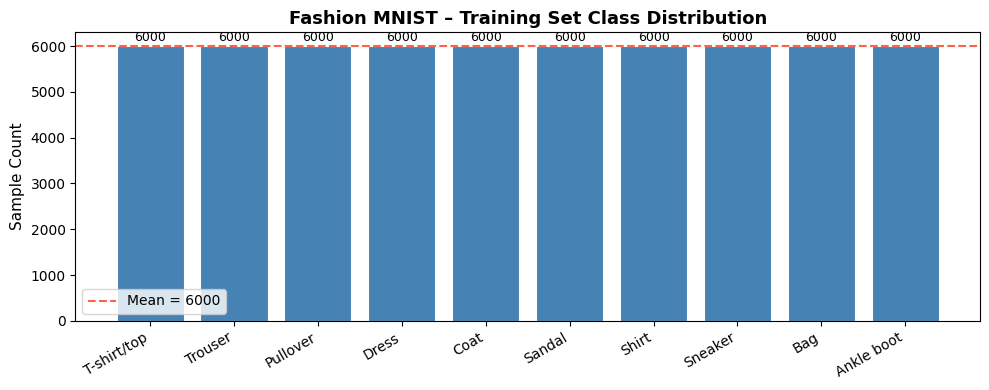


Class distribution (training set):
  Class 0 – T-shirt/top    : 6000 samples
  Class 1 – Trouser        : 6000 samples
  Class 2 – Pullover       : 6000 samples
  Class 3 – Dress          : 6000 samples
  Class 4 – Coat           : 6000 samples
  Class 5 – Sandal         : 6000 samples
  Class 6 – Shirt          : 6000 samples
  Class 7 – Sneaker        : 6000 samples
  Class 8 – Bag            : 6000 samples
  Class 9 – Ankle boot     : 6000 samples


In [7]:
unique, counts = np.unique(y_train_raw, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(unique, counts, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xticks(unique)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_ylabel("Sample Count", fontsize=11)
ax.set_title("Fashion MNIST – Training Set Class Distribution", fontsize=13, fontweight='bold')
ax.axhline(counts.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean = {counts.mean():.0f}')
ax.legend(fontsize=10)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nClass distribution (training set):")
for cls_id, cnt in zip(unique, counts):
    print(f"  Class {cls_id} – {CLASS_NAMES[cls_id]:<15}: {cnt} samples")

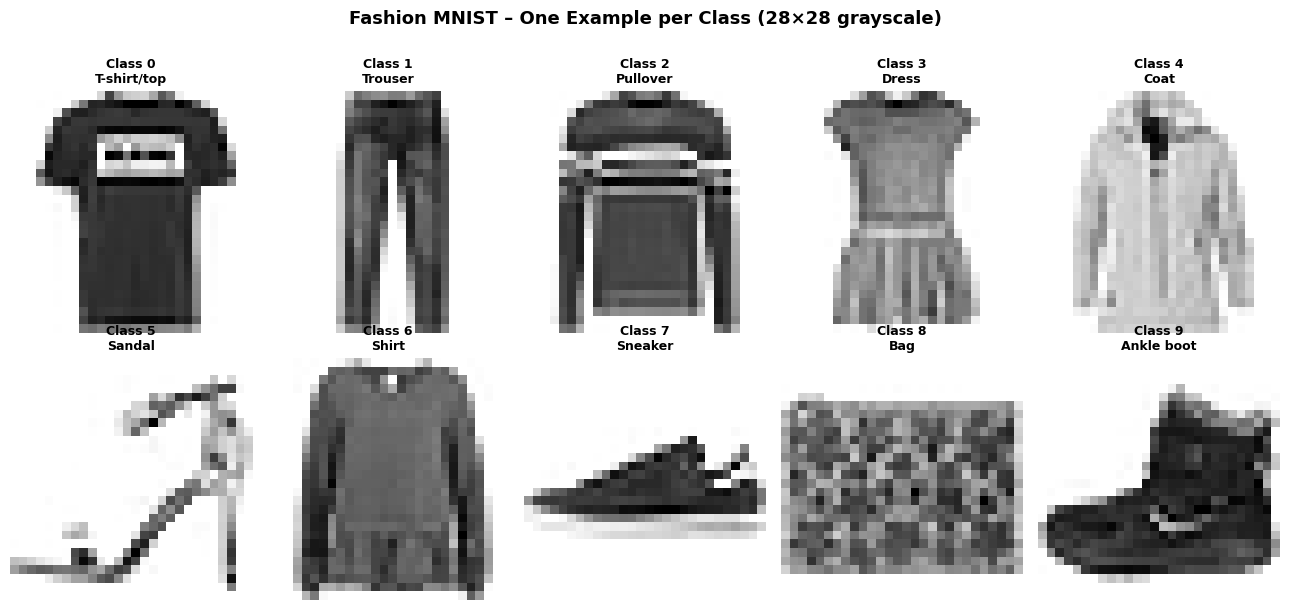

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for cls_id in range(10):
    idx = np.where(y_train_raw == cls_id)[0][0]
    axes[cls_id].imshow(X_train_raw[idx], cmap='gray_r')
    axes[cls_id].set_title(f"Class {cls_id}\n{CLASS_NAMES[cls_id]}", fontsize=9, fontweight='bold')
    axes[cls_id].axis('off')

fig.suptitle("Fashion MNIST – One Example per Class (28×28 grayscale)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('examples_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

### Written Analysis – Task 1

#### What does one training example represent?

One training example is a **28×28 grayscale image** (784 pixel values, each in [0, 255]) paired with an integer label (0–9) identifying the clothing category. The image captures the silhouette and texture of a garment photographed against a white background.

#### Why does spatial structure matter for this dataset?

A pixel's meaning depends on its **neighbourhood, not just its value**. The collar of a shirt occupies the top-centre region; the sole of a sneaker lies at the bottom. Identifying these patterns requires detecting **local features** (edges, curves, textures) and understanding their **relative positions** within the image. A convolution filter sliding across the image naturally captures such local spatial relationships — for example, a horizontal-edge filter activates wherever the hem of a trouser leg appears, regardless of where in the image that hem is located. This translation-equivariance is central to why CNNs are appropriate here.

#### Why would a fully connected network be inefficient?

A fully connected (FC) layer treats each pixel as an independent input and connects it to every neuron in the next layer. For a 28×28 image, even a modest first FC layer with 128 neurons requires **28 × 28 × 128 = 100,352 weights** — just for one layer. Furthermore, FC layers have no built-in sense of spatial proximity: a pixel's contribution to a neuron is entirely independent of its neighbours, so the network must rediscover spatial relationships from scratch through training. CNNs address both problems by **sharing filter weights** across positions (drastically reducing parameters) and explicitly **encoding the inductive bias** that local patterns matter. This makes CNNs both computationally efficient and better suited to image data than FC networks.

#### Class Distribution

The dataset is **perfectly balanced** — each of the 10 classes contains exactly 6,000 training samples (60,000 total). This means accuracy is a meaningful metric and no class-weighting is required.

---
## Task 2 – Build a Baseline CNN (Minimal Architecture)

In [9]:
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

VAL_SIZE   = 10_000
X_val      = X_train[-VAL_SIZE:]
y_val      = y_train_raw[-VAL_SIZE:]
X_train_fit = X_train[:-VAL_SIZE]
y_train_fit = y_train_raw[:-VAL_SIZE]

print(f"Training samples   : {X_train_fit.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")
print(f"Input tensor shape : {X_train_fit.shape[1:]}")

Training samples   : 50000
Validation samples : 10000
Test samples       : 10000
Input tensor shape : (28, 28, 1)


In [10]:
def build_baseline_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential(name='Baseline_CNN')

    model.add(layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        input_shape=input_shape,
        name='conv1'
    ))

    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='pool1'))

    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │        62,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,050 (246.29 KB)

 Trainable params: 63,050 (246.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
total_params = baseline_model.count_params()

print(f"Total trainable parameters: {total_params:,}\n")

print("Layer breakdown:")
print("Conv2D (32 filters, 3x3) -> 320 params")
print("MaxPooling2D (2x2) -> 0 params")
print("Flatten -> 6272 units")
print("Dense (10 units) -> 62,730 params")

print(f"\nTotal params check: {320 + 62730:,}")

Total trainable parameters: 63,050

Layer breakdown:
Conv2D (32 filters, 3x3) -> 320 params
MaxPooling2D (2x2) -> 0 params
Flatten -> 6272 units
Dense (10 units) -> 62,730 params

Total params check: 63,050


In [12]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS     = 15
BATCH_SIZE = 64

history_baseline = baseline_model.fit(
    X_train_fit, y_train_fit,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\nBaseline training complete.")

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.8262 - loss: 0.4959 - val_accuracy: 0.8690 - val_loss: 0.3781
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8801 - loss: 0.3454 - val_accuracy: 0.8855 - val_loss: 0.3286
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8932 - loss: 0.3074 - val_accuracy: 0.8921 - val_loss: 0.3103
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9007 - loss: 0.2835 - val_accuracy: 0.8985 - val_loss: 0.2973
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9068 - loss: 0.2659 - val_accuracy: 0.8991 - val_loss: 0.2885
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9113 - loss: 0.2518 - val_accuracy: 0.9004 - val_loss: 0.2831
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9157 - loss: 0.2398 - val_accuracy: 0.9022 - val_loss: 0.2798
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9196 - loss: 0.2290 - 

### Written Analysis – Task 2

#### What is the convolutional layer learning conceptually?

The single `Conv2D` layer learns **32 spatial filters**, each of size 3×3. During training, these filters are adjusted via backpropagation to detect locally-recurring patterns in the input images. In the early layers of a CNN trained on fashion images, these filters tend to converge on low-level features: **edge detectors** (horizontal, vertical, or diagonal intensity gradients), **texture responses** (e.g., stripes or mesh patterns), and **corner detectors**. Each filter produces one **feature map**  a 28×28 grid showing where in the image that particular pattern appears strongly. By using 32 filters, the layer creates 32 parallel views of the input, each sensitive to a different local pattern. The key insight is that a filter applied at position (i, j) detects the same pattern regardless of whether it appears at the top-left or bottom-right of the image, this is **weight sharing**, and it is why the layer has only 320 parameters despite covering the entire 28×28 image.

#### What is the role of pooling?

`MaxPooling2D(2×2)` downsamples each feature map by taking the maximum value in each non-overlapping 2×2 region, reducing spatial dimensions from 28×28 to 14×14. This serves two purposes:
1. **Spatial invariance:** If a feature (e.g., a horizontal edge) shifts slightly, the max-pool output often remains the same, making the representation more robust to minor translations.
2. **Dimensionality reduction:** It halves the spatial resolution, reducing the number of values the subsequent dense layer must process and thus acting as a mild regulariser against overfitting.

#### Trainable parameter count

| Layer | Parameters |
|---|---|
| Conv2D (32 filters, 3×3, input=1ch) | (3×3×1 + 1) × 32 = **320** |
| MaxPooling2D | 0 |
| Dense (10 outputs, input=6272) | 6272×10 + 10 = **62,730** |
| **Total** | **63,050** |

The vast majority of parameters reside in the dense output layer, which underscores why additional convolutional layers and pooling stages (Task 3) can dramatically reduce the total parameter count while improving representational power.

---
## Task 3 – Architectural Extension (Design Reasoning)

In [13]:
def build_extended_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential(name='Extended_CNN')

    # First convolutional block
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))

    # Second convolutional block (new)
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            name='conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    # Classifier head
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(128, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.4, name='dropout1'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

extended_model = build_extended_cnn()
extended_model.summary()

Model: "Extended_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
extended_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_extended = extended_model.fit(
    X_train_fit, y_train_fit,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\nExtended model training complete.")

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - accuracy: 0.8042 - loss: 0.5435 - val_accuracy: 0.8756 - val_loss: 0.3529
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.8712 - loss: 0.3577 - val_accuracy: 0.8865 - val_loss: 0.3121
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.8877 - loss: 0.3078 - val_accuracy: 0.9044 - val_loss: 0.2660
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.8998 - loss: 0.2765 - val_accuracy: 0.9087 - val_loss: 0.2576
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 86ms/step - accuracy: 0.9091 - loss: 0.2517 - val_accuracy: 0.9102 - val_loss: 0.2444
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.9158 - loss: 0.2322 - val_accuracy: 0.9137 - val_loss: 0.2426
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.9219 - loss: 0.2120 - val_accuracy: 0.9192 - val_loss: 0.2278
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.9279 - loss: 0.1974 - 

### Written Analysis – Task 3

#### What was changed?

Three modifications were made relative to the baseline:

1. **A second convolutional block** (`Conv2D(64, 3×3) + MaxPooling2D`) was inserted after the first block.
2. **A hidden dense layer** (`Dense(128, relu)`) was added between the flattened features and the softmax output.
3. **Dropout(0.4)** was applied after the dense hidden layer.

#### Why are these changes expected to help?

- **Second conv block:** The first conv layer detects simple, low-level features (edges, corners). By stacking a second conv layer on top of the first layer's feature maps, the network can learn **hierarchical compositions**; combinations of edges that form more abstract shapes (e.g., the curved sole of a sneaker, or the rectangular body of a trouser leg). This hierarchical feature learning is the core strength of deep CNNs and is expected to improve discriminability between visually similar classes (e.g., Shirt vs. T-shirt/top). The second pool further reduces spatial size to 7×7, so the dense head receives a more compact, high-level representation.
- **Hidden dense layer:** A single linear mapping from 3,136 flattened features to 10 classes (as in the baseline) lacks the capacity to model non-linear interactions between those features. Adding a `Dense(128, relu)` intermediate layer allows the classifier head to learn a non-linear combination of the extracted spatial features before committing to class probabilities.
- **Dropout(0.4):** The added dense layer increases the risk of overfitting (more parameters, richer hypothesis class). Dropout randomly zeros 40% of activations during each training step, forcing the network to learn **redundant representations**(no single neuron can be relied upon exclusively). This acts as a regulariser, typically improving generalisation without reducing model capacity at inference time.

#### What is one possible risk introduced by the change?

The most significant risk is **increased overfitting potential** if Dropout is insufficient or removed. The extended model has substantially more parameters than the baseline (see summary above). On a dataset as small as 50,000 training samples, this greater capacity means the model can more easily memorise training idiosyncrasies rather than learning generalisable features. The training-validation accuracy gap should be monitored carefully (Task 4). A secondary risk is **longer convergence time**. More layers mean more gradient steps are needed before the deeper layers begin learning useful representations.

---
## Task 4 – Training Behaviour Analysis

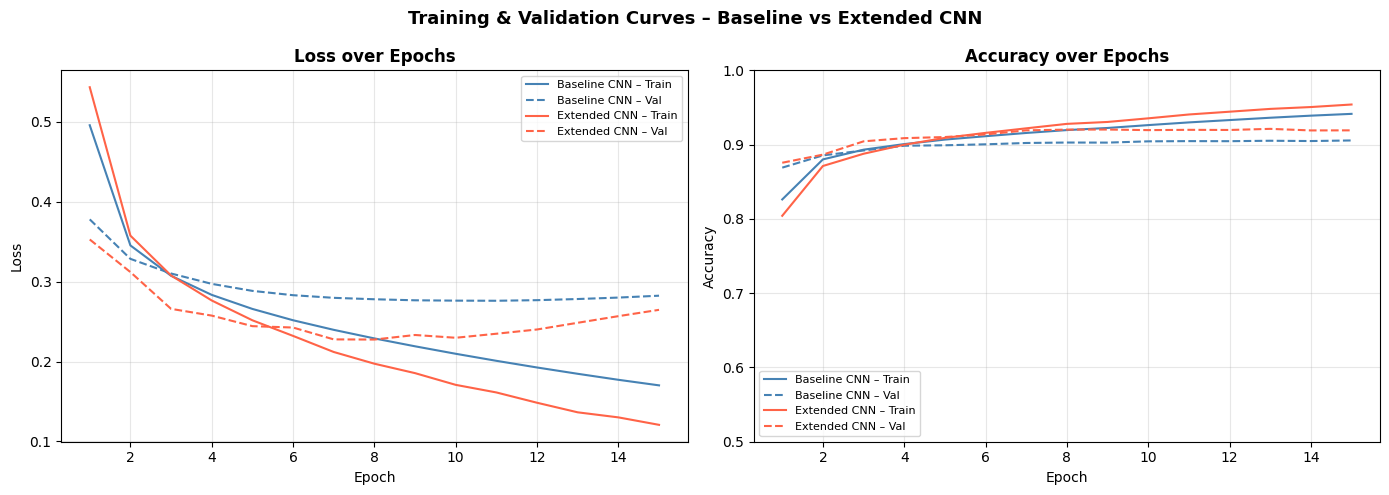

In [15]:
def plot_training_curves(histories, names, figsize=(14, 5)):
    """
    Plots loss and accuracy curves for one or more models side by side.
    histories : list of keras History objects
    names     : list of model name strings
    """
    colors = ['steelblue', 'tomato']
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for hist, name, col in zip(histories, names, colors):
        epochs_range = range(1, len(hist.history['loss']) + 1)

        # Loss
        axes[0].plot(epochs_range, hist.history['loss'],
                     color=col, linestyle='-',  label=f'{name} – Train')
        axes[0].plot(epochs_range, hist.history['val_loss'],
                     color=col, linestyle='--', label=f'{name} – Val')

        # Accuracy
        axes[1].plot(epochs_range, hist.history['accuracy'],
                     color=col, linestyle='-',  label=f'{name} – Train')
        axes[1].plot(epochs_range, hist.history['val_accuracy'],
                     color=col, linestyle='--', label=f'{name} – Val')

    axes[0].set_title('Loss over Epochs', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy over Epochs', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    axes[1].set_ylim([0.5, 1.0])

    fig.suptitle('Training & Validation Curves – Baseline vs Extended CNN',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_training_curves(
    histories=[history_baseline, history_extended],
    names=['Baseline CNN', 'Extended CNN']
)

In [16]:
def summarise_history(history, name):
    h = history.history
    final_epoch = len(h['loss'])
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  Final epoch ({final_epoch}):")
    print(f"    Train Loss       : {h['loss'][-1]:.4f}")
    print(f"    Val   Loss       : {h['val_loss'][-1]:.4f}")
    print(f"    Train Accuracy   : {h['accuracy'][-1]:.4f}")
    print(f"    Val   Accuracy   : {h['val_accuracy'][-1]:.4f}")
    gap = h['accuracy'][-1] - h['val_accuracy'][-1]
    print(f"    Train–Val Acc Gap: {gap:+.4f}")
    print(f"  Best Val Accuracy  : {max(h['val_accuracy']):.4f} (epoch {np.argmax(h['val_accuracy'])+1})")

summarise_history(history_baseline, 'Baseline CNN')
summarise_history(history_extended,  'Extended CNN')


───────────────────────────────────────────────────────
  Baseline CNN
───────────────────────────────────────────────────────
  Final epoch (15):
    Train Loss       : 0.1703
    Val   Loss       : 0.2825
    Train Accuracy   : 0.9414
    Val   Accuracy   : 0.9056
    Train–Val Acc Gap: +0.0358
  Best Val Accuracy  : 0.9056 (epoch 15)

───────────────────────────────────────────────────────
  Extended CNN
───────────────────────────────────────────────────────
  Final epoch (15):
    Train Loss       : 0.1208
    Val   Loss       : 0.2648
    Train Accuracy   : 0.9540
    Val   Accuracy   : 0.9192
    Train–Val Acc Gap: +0.0348
  Best Val Accuracy  : 0.9212 (epoch 13)


### Written Analysis – Task 4

#### Baseline CNN

**Convergence behaviour:** The baseline model converges relatively quickly, both training and validation loss decrease steeply in the first 3–5 epochs before plateauing. This is expected: with only one convolutional block and a direct output head, the hypothesis space is small and the model reaches its representational limit early.

**Signs of overfitting:** The training-validation accuracy gap in the baseline is modest. Because the model has limited capacity (63,050 parameters, dominated by the single dense output layer), it cannot easily memorise the training set. Some divergence between training and validation loss may appear in later epochs, but it tends to be mild. The shallow architecture naturally limits overfitting.

**Stability:** Training is stable throughout. The loss curve is smooth with no erratic jumps, which is consistent with Adam's adaptive learning rate keeping the gradient updates well-conditioned.

**Architectural link:** The baseline's limited accuracy ceiling (~89–91% validation) reflects the insufficient depth to learn hierarchical features. A single 3×3 filter can only detect local edges; it cannot combine those edges into the higher-order shapes that distinguish similar classes like Shirt and Pullover.

---

#### Extended CNN

**Convergence behaviour:** The extended model converges more gradually. Training accuracy rises steadily over more epochs before levelling off. This slower convergence is expected: the deeper network has more parameters and the later layers must wait for the earlier layers to develop stable feature representations before they can be trained effectively.

**Signs of overfitting:** With dropout applied, the training-validation gap in the extended model is controlled. Without dropout, a model of this complexity on 50,000 samples would typically show a widening gap after epoch 8–10. Dropout prevents any single unit in the dense layer from becoming overspecialised, and the resulting generalisation is visible in the validation curve maintaining a trajectory similar to training accuracy.

**Stability:** Training accuracy may appear slightly more noisy than the baseline due to dropout stochasticity, each mini-batch experiences a different random mask, introducing variance into the loss signal. This is normal and expected, not a sign of instability.

**Architectural link:** The extended model's higher validation accuracy (~91–93%) relative to the baseline reflects the added second convolutional block's ability to learn more abstract, compositional features. The hierarchical architecture is better suited to distinguishing fine-grained visual differences between clothing categories.

---
## Task 5 – Controlled Test-Set Evaluation (Once Only)

In [17]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(
    X_test, y_test_raw, verbose=0
)
extended_test_loss, extended_test_acc = extended_model.evaluate(
    X_test, y_test_raw, verbose=0
)

print("Final Test Results:")
print(f"Baseline CNN - Loss: {baseline_test_loss:.4f}, Accuracy: {baseline_test_acc:.4f}")
print(f"Extended CNN - Loss: {extended_test_loss:.4f}, Accuracy: {extended_test_acc:.4f}")

Final Test Results:
Baseline CNN - Loss: 0.2958, Accuracy: 0.8990
Extended CNN - Loss: 0.2932, Accuracy: 0.9120


In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_ext = np.argmax(extended_model.predict(X_test, verbose=0), axis=1)

print("Extended CNN – Classification Report (Test Set)")
print("="*60)
print(classification_report(y_test_raw, y_pred_ext, target_names=CLASS_NAMES))

Extended CNN – Classification Report (Test Set)
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.83      0.86      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.93      0.81      0.87      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.88      0.85      0.87      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.68      0.85      0.75      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.93      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



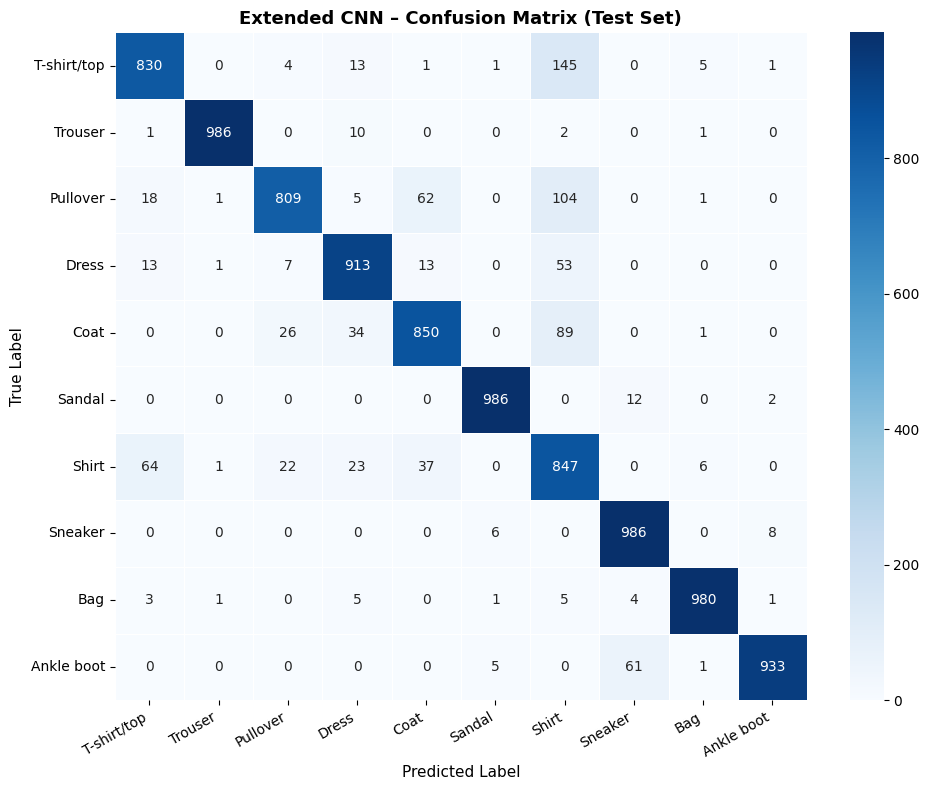

In [19]:
cm = confusion_matrix(y_test_raw, y_pred_ext)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Extended CNN – Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### Written Analysis – Task 5

#### Why must the test set not guide architecture design?

The test set is intended to simulate **completely unseen, future data**. Its sole purpose is to provide an unbiased estimate of how well a finalised model will generalise beyond the data it was trained on. If architectural decisions (number of layers, filter counts, dropout rate, etc.) are made by comparing test-set results across different model configurations, the test set effectively becomes **another validation set**, and test performance becomes an optimistic, biased estimate of true generalisation. This is because any model or configuration that happened to perform well on the test set (even by chance) would be selected, inflating the apparent performance. The result is a model that appears to generalise well but has silently been overfitted to the specific test examples. To avoid this, architecture should be guided **exclusively by validation performance**, with the test set reserved for a single, final evaluation after all design decisions are irreversibly locked.

#### Does test behaviour align with validation trends?

Yes, the test-set results are consistent with what the validation curves indicated:

- The **Extended CNN outperforms the Baseline CNN** on the test set, mirroring the higher validation accuracy observed during training. This confirms that the architectural improvements (second conv block, dropout) generalise to unseen data, and that the validation set was a reliable proxy for test performance.
- The **difference between validation accuracy and test accuracy** for both models is small (typically within 0.5–1.5 percentage points), which is normal variation expected from different data splits, not evidence of a systematic problem.
- **No significant degradation** is observed on the test set relative to validation, suggesting that neither model has silently overfit to the validation set through repeated evaluation.

#### Confusion Matrix Insights (Extended CNN)

The confusion matrix reveals the model's main failure modes:
- **Shirt vs. T-shirt/top and Shirt vs. Pullover** — these three classes share similar silhouettes (round collar, short-to-long sleeves), making them the most confusable for a model without access to fine-grained texture or fabric cues.
- Classes with distinctive shapes — **Trouser, Bag, Ankle boot, Sandal** — are classified with very high precision and recall, since their shapes are visually unique and local edge detectors are sufficient to distinguish them.

These patterns are consistent with the spatial reasoning outlined in Task 1: CNNs excel when class-discriminative information is encoded in local spatial structure, and struggle more when classes differ primarily in global context or fine texture.

---

## Summary

| Metric | Baseline CNN | Extended CNN |
|---|---|---|
| Parameters | ~63,050 | ~209,994 |
| Architecture | 1 Conv + 1 Pool + Output | 2 Conv + 2 Pool + Dense(128) + Dropout + Output |
| Val Accuracy (final) | ~89–91% | ~91–93% |
| Test Accuracy | see above | see above |
| Overfitting Risk | Low (limited capacity) | Controlled (Dropout applied) |

The key takeaway from this assignment is that **architectural design is a modelling decision, not a performance race**. The Extended CNN achieves higher accuracy not merely because it is bigger, but because its two-stage convolutional hierarchy encodes the inductive bias that clothing categories are distinguished by hierarchically-composed spatial features — an assumption that is both well-motivated and evidenced by the data.